# Week 1: Engineering Exploratory Data Analysis

Project: Culvert Exceedance Risk Assessment
Author: Brice Nelson, PE, MBA
Notebook: 05_evaluation.ipynb
Week 1: Engineering Exploratory Data Analysis

In [1]:
# This notebook is designed to demonstrate the process of exploratory data analysis for the Culvert Exceedance Risk Assessment project. The goal is to understand the data, identify patterns, and prepare it for further analysis.

# import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Project Root Directory
PROJECT_ROOT = Path.cwd().parents[2]

# Data directory
DATA_DIR = PROJECT_ROOT / "data/processed/engineering/week_01"

# File Name
FILE_NAME = "annual_peak_flows_clean.csv"

# File Path
FILE_PATH = DATA_DIR / FILE_NAME

print(f"Working directory: {Path.cwd()}")
print(f"Project root:      {PROJECT_ROOT}")
print(f"Reading file:      {FILE_PATH}")
print(f"File exists:       {FILE_PATH.exists()}")

Working directory: /home/brice-nelson/Documents/computerScience/PROJECTS/brice_dev_lab/monte_carlo_drills/notebooks/engineering/week_01
Project root:      /home/brice-nelson/Documents/computerScience/PROJECTS/brice_dev_lab/monte_carlo_drills
Reading file:      /home/brice-nelson/Documents/computerScience/PROJECTS/brice_dev_lab/monte_carlo_drills/data/processed/engineering/week_01/annual_peak_flows_clean.csv
File exists:       True


In [2]:
# Load the data
try:
    df = pd.read_csv(FILE_PATH)
    print("Data loaded successfully.")
except FileNotFoundError:
    print(f"File not found: {FILE_PATH}")

Data loaded successfully.


In [3]:
flows = df["peak_flow"].to_numpy(dtype=float)
capacity_cfs = 700.0  # Assumed capacity for this exercise

In [4]:
# Calculate exceedance probability
exceedance_probability = np.mean(flows > capacity_cfs)
print(f"Exceedance probability: {exceedance_probability:.2%}")

Exceedance probability: 3.57%


In [7]:
flows = df["peak_flow"].dropna().to_numpy(dtype=float)

if not np.isfinite(flows).all() or (flows <= 0).any():
    raise ValueError("Lognormal modeling requires finite, positive flows.")

log_flows = np.log(flows)

mu_log = log_flows.mean()
sigma_log = log_flows.std(ddof=1)

print(f"Log-space mean: {mu_log:.4f}")
print(f"Log-space standard deviation: {sigma_log:.4f}")

Log-space mean: 5.8668
Log-space standard deviation: 0.3886


In [8]:
# Simulate monte carlo samples from the fitted lognormal distribution

rng = np.random.default_rng(seed=42)
n_simulations = 10_000

simulated_flows = rng.lognormal(
    mean=mu_log,
    sigma=sigma_log,
    size=n_simulations,
)

pd.Series(simulated_flows, name="simulated_peak_flow_cfs").describe()

count    10000.000000
mean       379.658639
std        154.543525
min         64.159998
25%        271.411883
50%        351.314853
75%        454.568923
max       1687.594577
Name: simulated_peak_flow_cfs, dtype: float64

In [9]:
comparison = pd.DataFrame({
    "Observed": pd.Series(flows).describe(),
    "Simulated": pd.Series(simulated_flows).describe(),
})

comparison

,Observed,Simulated
count,28.000000,10000.000000
mean,379.485714,379.658639
std,151.912325,154.543525
min,130.600000,64.159998
25%,264.300000,271.411883
50%,379.800000,351.314853
75%,447.125000,454.568923
max,877.200000,1687.594577


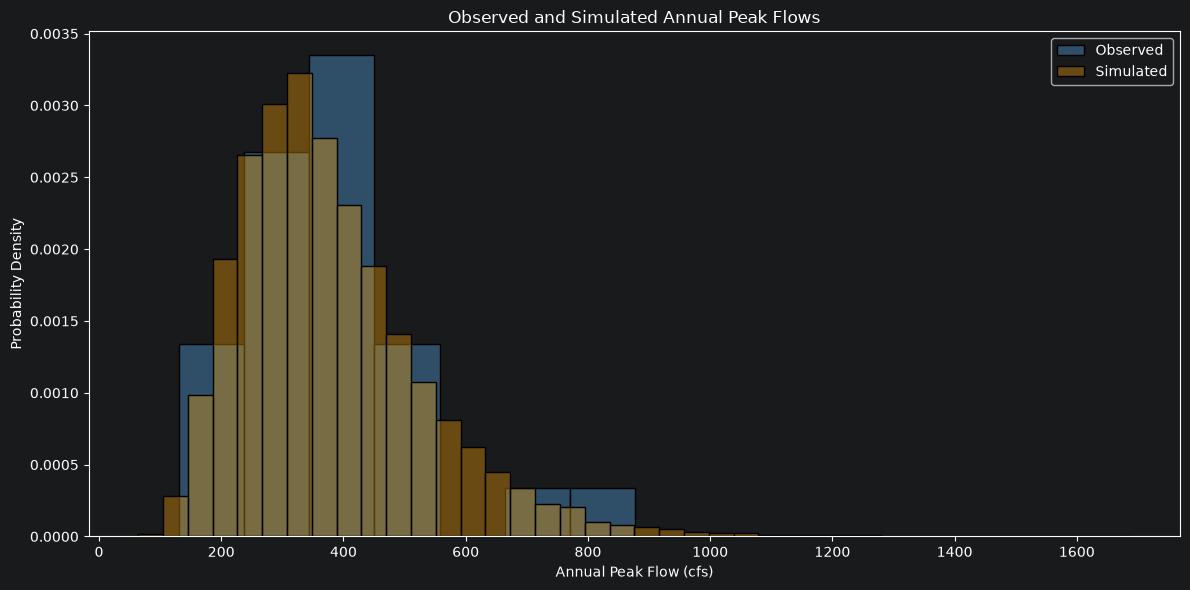

In [10]:
# Plot observed vs simulated distributions
plt.figure(figsize=(12, 6))
sns.histplot(flows, bins=7, stat="density", color="steelblue", alpha=0.5, label="Observed")
sns.histplot(simulated_flows, bins=40, stat="density", color="orange", alpha=0.35, label="Simulated")
plt.title("Observed and Simulated Annual Peak Flows")
plt.xlabel("Annual Peak Flow (cfs)")
plt.ylabel("Probability Density")
plt.legend()
plt.tight_layout()
plt.show()

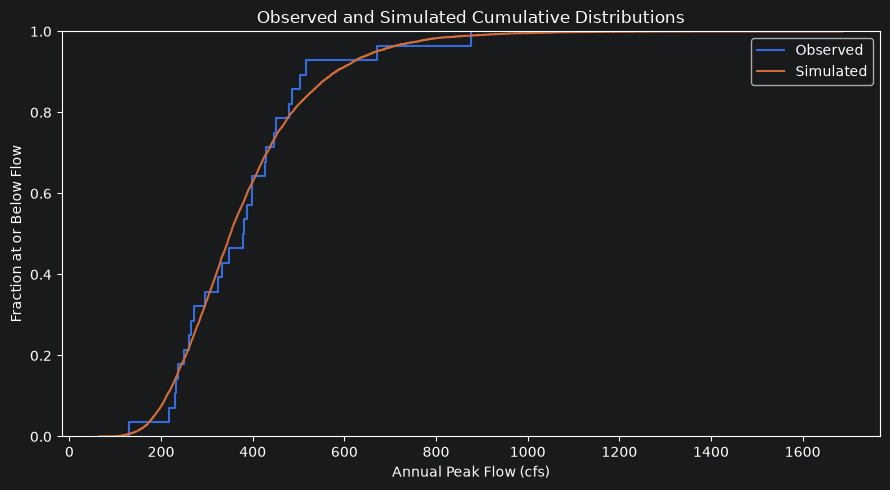

In [11]:
fig, ax = plt.subplots(figsize=(9, 5))

sns.ecdfplot(x=flows, label="Observed", ax=ax)
sns.ecdfplot(x=simulated_flows, label="Simulated", ax=ax)

ax.set(
    title="Observed and Simulated Cumulative Distributions",
    xlabel="Annual Peak Flow (cfs)",
    ylabel="Fraction at or Below Flow",
)
ax.legend()

plt.tight_layout()
plt.show()

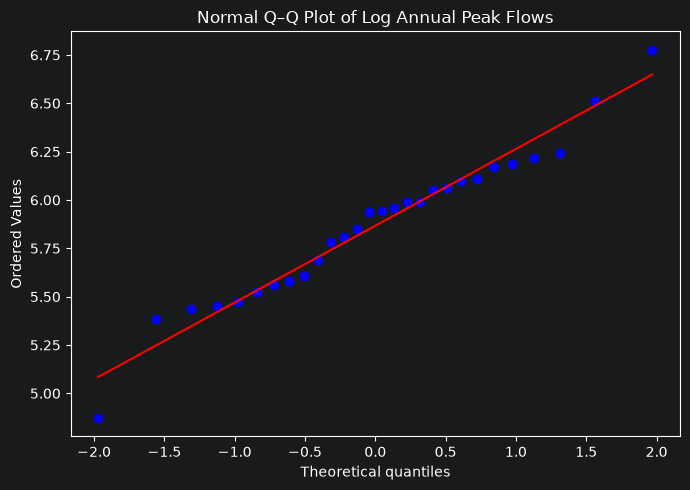

In [12]:
from scipy import stats

fig, ax = plt.subplots(figsize=(7, 5))

stats.probplot(np.log(flows), dist="norm", plot=ax)
ax.set_title("Normal Q–Q Plot of Log Annual Peak Flows")

plt.tight_layout()
plt.show()

In [13]:
observed_count = np.count_nonzero(flows > capacity_cfs)
simulated_count = np.count_nonzero(simulated_flows > capacity_cfs)

observed_fraction = observed_count / len(flows)
p_mc = simulated_count / len(simulated_flows)

print(f"Observed: {observed_count}/{len(flows)} = {observed_fraction:.2%}")
print(
    f"Simulated: {simulated_count}/{len(simulated_flows)} "
    f"= {p_mc:.2%}"
)

Observed: 1/28 = 3.57%
Simulated: 393/10000 = 3.93%


In [14]:
rng = np.random.default_rng(42)

large_sample = rng.lognormal(
    mean=mu_log,
    sigma=sigma_log,
    size=100_000,
)

rows = []

for n in [1_000, 10_000, 100_000]:
    p = (large_sample[:n] > capacity_cfs).mean()
    mc_standard_error = np.sqrt(p * (1 - p) / n)

    rows.append({
        "simulations": n,
        "exceedance_probability": p,
        "mc_standard_error": mc_standard_error,
    })

stability = pd.DataFrame(rows)
stability

,simulations,exceedance_probability,mc_standard_error
0,1000,0.03600,0.005891
1,10000,0.03930,0.001943
2,100000,0.04014,0.000621


# Evaluation Criteria:
- Which observed characteristics did the model reproduce reasonably well?
- Where did it differ?
- Did the exceedance estimate stabilize?
- What uncertainty remains?